# DNN — TensorFlow / Keras (CPU)

## Model: Deep Neural Network (Multi-Layer Perceptron)
- **Dataset**: UCI HAR — 7,352 train / 2,947 test, 561 sensor features
- **Task**: Classify 6 human activities (3 dynamic, 3 static)
- **Framework showcase**: Keras Callbacks — EarlyStopping + ReduceLROnPlateau + TensorBoard-ready history

## CPU Strategy
- TF 2.11+ dropped native Windows GPU support — all ops run on CPU
- Keras `Sequential` API for model building (high-level, production-oriented)
- Built-in `model.fit()` with validation_split, callbacks, and automatic history tracking
- No manual training loop needed — Keras handles epochs, batches, metrics internally

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import tensorflow as tf
from tensorflow import keras

sys.path.append('../..')

from utils.data_loader import load_processed_data
from utils.visualization import (plot_confusion_matrix_multiclass,
                                  plot_per_class_f1, plot_training_history)
from utils.metrics import evaluate_classifier
from utils.performance import track_performance, track_inference, get_model_size
from utils.results import build_results_dict, save_results, add_result, print_comparison

RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Configuration
RANDOM_STATE = 113
FRAMEWORK = "TensorFlow"
N_CLASSES = 6
BATCH_SIZE = 64
ACTIVITY_NAMES = [
    "WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
    "SITTING", "STANDING", "LAYING"
]

# Reproducibility
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Load preprocessed UCI HAR
X_train, X_test, y_train, y_test, meta = load_processed_data('dnn')

print("=" * 60)
print(f"[1/8] Data loaded — {FRAMEWORK} DNN")
print("=" * 60)
print(f"  Device: CPU (TF 2.11+ dropped native Windows GPU)")
print(f"  TF version: {tf.__version__}")
print(f"  Train: {X_train.shape} | Test: {X_test.shape}")
print(f"  Classes: {N_CLASSES} ({', '.join(ACTIVITY_NAMES)})")
print(f"  Label range: [{y_train.min()}, {y_train.max()}]")
print(f"  Dtype: {X_train.dtype}")

[1/8] Data loaded — TensorFlow DNN
  Device: CPU (TF 2.11+ dropped native Windows GPU)
  TF version: 2.20.0
  Train: (7352, 561) | Test: (2947, 561)
  Classes: 6 (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING)
  Label range: [0, 5]
  Dtype: float32


In [2]:
# Step 2: Simple baseline — Keras Sequential API

"""
Keras handles training loop, batching, validation split, and history internally
This is the key TF advantage: model.fit() replaces 30+ lines of manual training code
"""

print("=" * 60)
print("[2/8] SIMPLE BASELINE DNN")
print("=" * 60)

baseline = keras.Sequential([
    keras.layers.Input(shape=(561,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(N_CLASSES, activation='softmax')
])

baseline.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # integer labels, no one-hot needed
    metrics=['accuracy']
)

# model.fit() handles batching, validation split, and epoch logging
history_base = baseline.fit(
    X_train, y_train,
    epochs=200,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=15, restore_best_weights=True
        )
    ],
    verbose=0  # silent — we'll print summary ourselves
)

y_pred_base = baseline.predict(X_test, verbose=0).argmax(axis=1)
base_metrics = evaluate_classifier(y_test, y_pred_base)

n_epochs = len(history_base.history['loss'])
best_val_acc = max(history_base.history['val_accuracy'])

print(f"\n  Architecture: 561 → 128 → 6")
print(f"  Epochs: {n_epochs} (best val_acc: {best_val_acc:.4f})")
print(f"  Final train loss: {history_base.history['loss'][-1]:.4f}")
print(f"\n  Test Results:")
print(f"    Accuracy: {base_metrics['accuracy']:.4f}")
print(f"    Macro F1: {base_metrics['macro_f1']:.4f}")


[2/8] SIMPLE BASELINE DNN

  Architecture: 561 → 128 → 6
  Epochs: 33 (best val_acc: 0.9823)
  Final train loss: 0.0013

  Test Results:
    Accuracy: 0.9365
    Macro F1: 0.9362


[3/8] TRAINING HISTORY


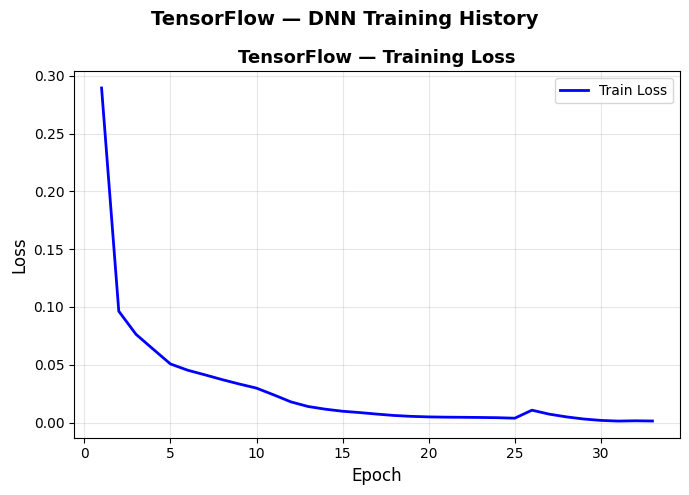

  Epochs: 33
  Loss: 0.2894 -> 0.0013
  Val acc: 0.9538 -> 0.9823


In [3]:
# Step 3: Visualize baseline training curves
# Keras history object automatically tracks loss + val_loss + accuracy + val_accuracy
print("=" * 60)
print("[3/8] TRAINING HISTORY")
print("=" * 60)

history = {
    'train_loss': history_base.history['loss'],
    'val_acc': history_base.history['val_accuracy']
}

plot_training_history(history, FRAMEWORK,
                      save_path=f'{RESULTS_DIR}/training_history_baseline.png')

print(f"  Epochs: {len(history_base.history['loss'])}")
print(f"  Loss: {history_base.history['loss'][0]:.4f} -> {history_base.history['loss'][-1]:.4f}")
print(f"  Val acc: {history_base.history['val_accuracy'][0]:.4f} -> {max(history_base.history['val_accuracy']):.4f}")